<a href="https://colab.research.google.com/github/shrey9903/project_visualizer/blob/main/project9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

data = None
last_fig = None

In [4]:

# LOAD DATA
def load_dataset():
    global data
    print(">"*20 + " Load Dataset " + "<"*20)
    path = input("Enter the path of Dataset (CSV file): ")
    print("^"*54)
    print(" ")
    try:
        data = pd.read_csv(path)
        print("✅Dataset loaded successfully!")
    except Exception as e:
        print("Error loading dataset:", e)

In [5]:
# EXPLORE DATA
def explore_data():
    if data is None:
        print("No dataset loaded!")
        return

    while True:
        print(">"*20 + " Explore Data " + "<"*20)
        print("1. Display First 5 Rows")
        print("2. Display Last 5 Rows")
        print("3. Display Column Names")
        print("4. Display Data Types")
        print("5. Display Basic Info")
        print("6. Back")
        print("="*55)
        choice = input("Enter choice: ")

        match choice:
            case "1":
                print(">"*20 + " First 5 Rows " + "<"*20)
                print(data.head())
                print("^"*55)
                print(" ")
            case "2":
                print(">"*20 + " Last 5 Rows " + "<"*20)
                print(data.tail())
                print("^"*55)
                print(" ")
            case "3":
                print(">"*20 + " Column Names " + "<"*20)
                print(data.columns.tolist())
                print("^"*55)
                print(" ")
            case "4":
                print(">"*20 + " Data Types " + "<"*20)
                print(data.dtypes)
                print("^"*55)
                print(" ")
            case "5":
                print(">"*20 + " Basic Info " + "<"*20)
                print(data.info())
                print("^"*55)
                print(" ")
            case "6":
                break
            case _:
                print("🛑Invalid choice!")
                print(" ")

In [6]:
# MISSING DATA
def handle_missing_data():
    global data
    if data is None:
        print("No dataset loaded!")
        return

    while True:
        print(">"*20 + " Handle Missing Data " + "<"*20)
        print("1. Show Missing Rows")
        print("2. Fill with Mean")
        print("3. Drop Missing Rows")
        print("4. Replace with Specific Value")
        print("5. Back")
        print("="*55)
        choice = input("Enter choice: ")
        print("-"*55)
        print(" ")

        match choice:
            case "1":
                print(data[data.isnull().any(axis=1)])
            case "2":
                numeric_cols = data.select_dtypes(include=np.number).columns
                data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())
                print("Missing values filled with mean.")
            case "3":
                data.dropna(inplace=True)
                print("Rows dropped successfully.")
            case "4":
                val = input("Enter replacement value: ")
                data.fillna(val, inplace=True)
                print("Missing values replaced.")
            case "5":
                break
            case _:
                print("Invalid choice!")

In [7]:

#  NUMPY OPERATIONS
def dataframe_operations():
    if data is None:
        print("No dataset loaded!")
        return

    numeric_cols = data.select_dtypes(include=np.number).columns
    print("Available Numeric Columns:", list(numeric_cols))
    col = input("Select column: ")

    if col not in numeric_cols:
        print("Invalid column!")
        return

    arr = data[col].to_numpy()

    print("Mean:", np.mean(arr))
    print("Sum:", np.sum(arr))
    print("Min:", np.min(arr))
    print("Max:", np.max(arr))
    print("First 5 values:", arr[:5])
    print("Last 5 values:", arr[-5:])

In [8]:
# STATISTICS
def generate_statistics():
    if data is None:
        print("No dataset loaded!")
        return

    numeric_cols = data.select_dtypes(include=np.number).columns
    col = input(f"Choose column {list(numeric_cols)}: ")

    if col not in numeric_cols:
        print("Invalid column!")
        return

    arr = data[col].to_numpy()

    print("Standard Deviation:", np.std(arr))
    print("Variance:", np.var(arr))
    print("25th Percentile:", np.percentile(arr, 25))
    print("Median:", np.percentile(arr, 50))
    print("75th Percentile:", np.percentile(arr, 75))
    print(data[col].describe())

In [9]:

# SEARCH / SORT / FILTER
def search_sort_filter():
    if data is None:
        print("No dataset loaded!")
        return

    print("\n1. Search")
    print("2. Sort")
    print("3. Filter")
    choice = input("Enter choice: ")

    match choice:
        case "1":
            col = input("Column name: ")
            val = input("Search value: ")
            print(data[data[col].astype(str).str.contains(val, case=False)])
        case "2":
            col = input("Column name: ")
            order = input("Ascending (y/n): ").lower() == "y"
            print(data.sort_values(by=col, ascending=order))
        case "3":
            col = input("Column name: ")
            val = input("Filter value: ")
            print(data[data[col] == val])
        case _:
            print("Invalid choice!")

In [10]:
#  VISUALIZATION
def data_visualization():
    global last_fig

    if data is None:
        print("No dataset loaded!")
        return

    print("\n== Visualization ==")
    print("1. Bar Plot")
    print("2. Line Plot")
    print("3. Scatter Plot")
    print("4. Pie Chart")
    print("5. Histogram")
    print("6. Stack Plot")
    print("7. Heatmap")
    print("8. Box Plot")

    choice = input("Enter choice: ")
    last_fig = plt.figure(figsize=(10,6))

    match choice:
        case "1":
            x = input("X column: ")
            y = input("Y column: ")
            sns.barplot(x=x, y=y, data=data)
        case "2":
            x = input("X column: ")
            y = input("Y column: ")
            sns.lineplot(x=x, y=y, data=data)
        case "3":
            x = input("X column: ")
            y = input("Y column: ")
            sns.scatterplot(x=x, y=y, data=data)
        case "4":
            col = input("Column: ")
            data[col].value_counts().plot.pie(autopct="%1.1f%%")
        case "5":
            col = input("Column: ")
            sns.histplot(data[col], bins=30)
        case "6":
            x = input("X column: ")
            y_cols = input("Y columns (comma separated): ").split(",")
            ys = [data[y.strip()] for y in y_cols]
            plt.stackplot(data[x], *ys, labels=y_cols)
            plt.legend()
        case "7":
            sns.heatmap(data.select_dtypes(np.number).corr(), annot=True)
        case "8":
            col = input("Column: ")
            sns.boxplot(y=data[col])
        case _:
            print("Invalid choice!")
            return


    plt.show()

In [11]:
#  SAVE VISUALIZATION
def save_visualizations():
    global last_fig
    if last_fig is None:
        print("No plot available!")
        return

    name = input("Enter file name (e.g. plot.png): ")
    last_fig.savefig(name)
    print("Plot saved successfully!")


========================= Data Analysis Program =========================
1. Load Dataset
2. Explore Data
3. DataFrame Operations (NumPy)
4. Handle Missing Data
5. Generate Statistics
6. Search / Sort / Filter
7. Data Visualization
8. Save Visualization
9. Exit
----------------------------------------------------------------------
Enter choice: 1
----------------------------------------------------------------------
>>>>>>>>>>>>>>>>>>>> Load Dataset <<<<<<<<<<<<<<<<<<<<
Enter the path of Dataset (CSV file): /content/sales_dataset_100_entries.csv
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
 
✅Dataset loaded successfully!

========================= Data Analysis Program =========================
1. Load Dataset
2. Explore Data
3. DataFrame Operations (NumPy)
4. Handle Missing Data
5. Generate Statistics
6. Search / Sort / Filter
7. Data Visualization
8. Save Visualization
9. Exit
----------------------------------------------------------------------
Enter choice: 2
----------

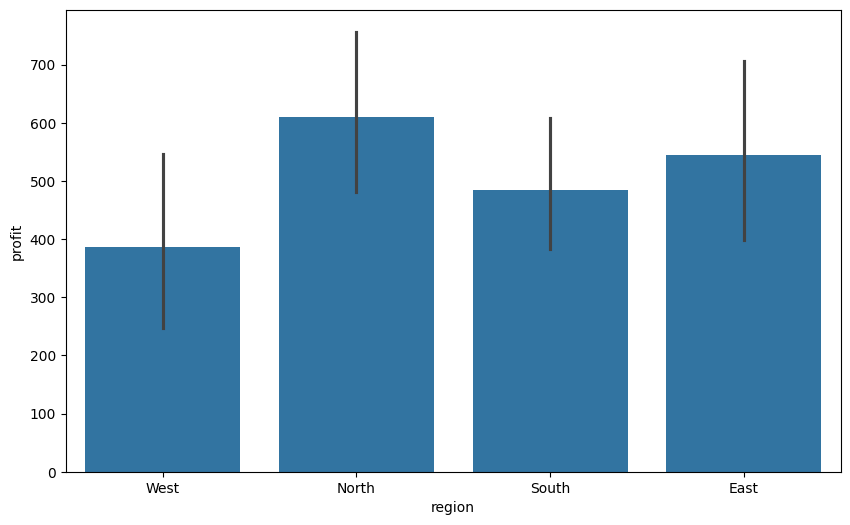


========================= Data Analysis Program =========================
1. Load Dataset
2. Explore Data
3. DataFrame Operations (NumPy)
4. Handle Missing Data
5. Generate Statistics
6. Search / Sort / Filter
7. Data Visualization
8. Save Visualization
9. Exit
----------------------------------------------------------------------
Enter choice: 8
----------------------------------------------------------------------
Enter file name (e.g. plot.png): project_plot.png
Plot saved successfully!

========================= Data Analysis Program =========================
1. Load Dataset
2. Explore Data
3. DataFrame Operations (NumPy)
4. Handle Missing Data
5. Generate Statistics
6. Search / Sort / Filter
7. Data Visualization
8. Save Visualization
9. Exit
----------------------------------------------------------------------
Enter choice: 9
----------------------------------------------------------------------
Exiting program. Goodbye!


In [12]:
#  MAIN MENU
def main():
    while True:
        print("\n" + "="*25 + " Data Analysis Program " + "="*25)
        print("1. Load Dataset")
        print("2. Explore Data")
        print("3. DataFrame Operations (NumPy)")
        print("4. Handle Missing Data")
        print("5. Generate Statistics")
        print("6. Search / Sort / Filter")
        print("7. Data Visualization")
        print("8. Save Visualization")
        print("9. Exit")

        print("-"*70)
        choice = input("Enter choice: ")
        print("-"*70)

        match choice:
            case "1": load_dataset()
            case "2": explore_data()
            case "3": dataframe_operations()
            case "4": handle_missing_data()
            case "5": generate_statistics()
            case "6": search_sort_filter()
            case "7": data_visualization()
            case "8": save_visualizations()
            case "9":
                print("Exiting program. Goodbye!")
                break
            case _:
                print("Invalid choice!")

if __name__ == "__main__":
    main()

In [ ]:
4